<a href="https://colab.research.google.com/github/apranav22/bayesian_nmor/blob/main/toy_bayesian_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import os
import sys
from scipy.stats import norm
from scipy.integrate import simpson

# tqdm import with safe fallback for environments without tqdm
try:
    from tqdm import tqdm
except Exception:
    def tqdm(iterable=None, *args, **kwargs):
        return iterable if iterable is not None else range(0)

# Global flag to toggle plotting
SHOW_PLOTS = False  # set to True to re-enable plots

global tou, delta, k2, transit_rate, lo

# spontaneous emission rate ~ 10^7 Hz
tou = 10**7
# detuning
delta = 0.1 * tou
# saturation parameter
k2 = 5.0
# transit rate
transit_rate = 0.01 * tou
# unsaturated absorption length
lo = 0.001

folder_path = r"C:\Users\Dinesh\UGP"
sys.path.insert(0, folder_path)


def alpha_th(B_tot):
    # gyromagnetic ratio ~ 10^6 Hz/Guass, larmor freq
    gyro = 1e7
    omega_l = gyro * (B_tot)
    D = (
        8
        * (omega_l**2)
        * (
            (32 * (tou**2) * (k2 + 3) * ((omega_l**2) + (delta**2)))
            + (192 * (((delta**2) - (omega_l**2)) ** 2))
            + ((tou**4) * (k2 + 2) * (k2 + 6))
        )
    ) + (
        2
        * (transit_rate**2)
        * (((tou**2) * ((2 * k2) + 3)) + (12 * (delta**2)))
        * (((tou**2) * ((k2 + 2) ** 2)) + (16 * (delta**2)))
    )
    alpha_th = (
        -6
        * tou
        * omega_l
        * (
            (
                8
                * (omega_l**2)
                * ((8 * (omega_l**2)) + ((tou**2) * (k2 + 2)) - (8 * (delta**2)))
            )
            + (
                transit_rate
                * (
                    (4 * transit_rate * ((tou**2) - ((2 * delta) ** 2)))
                    - ((tou**3) * k2 * (k2 + 2))
                )
            )
        )
        / D
    )
    return lo * alpha_th


def alpha_exp(alpha_th, sigma):
    return alpha_th + np.random.normal(0, sigma, size=alpha_th.shape)


B_unk = np.random.uniform(-1, 1)  # B_unknown can be anything between -1 and 1
print("True B value =", B_unk)
gamma = 0.02
sigma = 2e-5  # FIXME: This is not a percentage but an absolute value

B_bias = np.linspace(-5, 5, 1000)
B_tot = B_unk + B_bias

alpha_vals = alpha_th(B_tot)

alpha_exp_vals = alpha_exp(alpha_vals, sigma)
if SHOW_PLOTS:
    plt.figure()
    plt.plot(B_bias, alpha_exp_vals, color="blue")
    plt.plot(B_bias, alpha_vals, color="orange")
    plt.xlabel("B_bias")
    plt.ylabel("Measured alpha")

True B value = -0.0676083229787452


Frequentist Scheme:

1.   An experiment corresponds to a fixed Bias and measuring Alpha as a signal against time. We then obtain an averaged Alpha for the same.
2.   We then do a field scan, an dobtain a graph of alpha against Bias (which by itself is costly because we ARE PHYSICALLY doing those many experiment)
3. then we  simple fir the model that minimises least square loss

In [32]:
def MLE(B_unk, B_bias, sigma=2e-5, Test=0, num_samples=10):
    B_tot = B_unk + B_bias
    alpha_vals = alpha_th(B_tot)
    alpha_exp_vals = alpha_exp(alpha_vals, sigma)
    indices = np.where(alpha_vals <= 1e-21)
    # I've made this change so that the points are somewhat uniformly sampled around the sensitive points and not randomly at the tails
    # TODO add possible multiple alphas for each experimental run
    # TODO instead of uniform sampling, do weighted sampling based on sensitivity
    # TODO instead of uniform sampling, do gaussian sampling around zero point of the distribution

    i = indices[0][0]
    samples = np.random.uniform(
        # i - (B_bias.size // 4), i + (B_bias.size // 4), num_samples
        0, B_bias.size-1, num_samples,
    )
    samples = np.round(samples).astype(int)
    B_bias_samples = B_bias[samples]
    alpha_vals_exp_samples = alpha_exp_vals[samples]
    if SHOW_PLOTS:
        plt.plot(B_bias, alpha_vals, label="Theoretical Curve", color="orange")
        plt.scatter(
            B_bias_samples, alpha_vals_exp_samples, label="Sampled Data", color="red"
        )
    from scipy.optimize import curve_fit

    def alpha_model(B_total, B_unk_fit):
        B_tot_fit = B_unk_fit + B_total
        return alpha_th(B_tot_fit)

    initial_guess = [0.0]
    popt, pcov = curve_fit(
        alpha_model,
        B_bias_samples,
        alpha_vals_exp_samples,
        p0=initial_guess,
    )
    B_est_MLE = popt[0]
    print(
        popt[0],
        "+-",
        pcov[0][0] ** 0.5,
        "is the MLE-estimated value of B_unk, and the true value is",
        B_unk,
    )

    new_dir = "Tests/Test_{Test}".format(Test=Test)
    os.makedirs(new_dir, exist_ok=True)
    save_path = os.path.join(new_dir, f"MLE Output for True B{Test}.png".format(Test))
    if SHOW_PLOTS:
        plt.plot(
            B_bias,
            alpha_model(B_bias, *popt),
            color="green",
            linestyle="--",
            label="Fitted Curve",
        )
        plt.xlabel("B_bias")
        plt.ylabel("Measured alpha")
        plt.title("MLE Output for True B:" + str(popt[0]) + "+-" + str(pcov[0][0] ** 0.5))
        plt.legend()
        plt.savefig(save_path)
    return popt[0], pcov[0][0] ** 0.5

Bayesian Code Begins here

In [33]:
def alpha_theory(B_tot):
    return alpha_th(B_tot)

# likelihood for cp and also actual expression
def likelihood(alpha_meas, B_unknown, B_bias, sigma=0.05, Gamma=1.0):
    B_total = B_unknown + B_bias
    alpha_exp = alpha_theory(B_total)
    prefactor = 1.0 / (sigma * cp.sqrt(2 * np.pi))
    exponent = -((alpha_meas - alpha_exp) ** 2) / (2 * sigma**2)
    return prefactor * cp.exp(exponent)


def simpson_gpu(y, x):
    dx = x[1] - x[0]
    n = len(x)
    if n % 2 == 0:
        x = x[:-1]
        y = y[..., :-1]
    return (dx / 3.0 * cp.sum(y[..., 0:-1:2] + 4.0 * y[..., 1::2] + y[..., 2::2], axis=-1))

# Posterior update
def update_posterior(prior, measurements, B_grid, B_bias, sigma=0.05):
    post = prior.copy()
    for alpha_meas in measurements:
        L = likelihood(alpha_meas, B_grid, B_bias, sigma)
        post *= L
    post_sum = simpson_gpu(post, B_grid)
    if post_sum > 1e-12:
        post /= post_sum
    else:
        post = cp.ones_like(B_grid) / (B_grid.max() - B_grid.min())
    return post

# KL Divergence Utility
def expected_KL(B_bias, prior, B_grid, sigma=0.1, n_samples=10**3):
    alphas = cp.linspace(-0.1, 0.1, n_samples)
    alpha_grid, B_grid_2d = cp.meshgrid(alphas, B_grid, indexing="ij")
    L_matrix = likelihood(alpha_grid, B_grid_2d, B_bias, sigma)
    integrand_P_alpha = L_matrix * prior
    P_alpha = simpson_gpu(integrand_P_alpha, B_grid)
    norm_factors = P_alpha
    epsilon = 1e-15
    valid_indices = norm_factors > 0
    if not cp.any(valid_indices):
        return 0.0
    post_matrix = (integrand_P_alpha[valid_indices] / norm_factors[valid_indices, cp.newaxis])
    ratio = post_matrix / (prior[cp.newaxis, :] + epsilon)
    ratio[ratio <= 0] = epsilon
    log_ratio = cp.log(ratio)
    KL_integrand = post_matrix * log_ratio
    KL_integrand[cp.isnan(KL_integrand)] = 0.0
    KL_vals = simpson_gpu(KL_integrand, B_grid)
    P_alpha_sum = cp.sum(P_alpha[valid_indices])
    if P_alpha_sum == 0:
        return 0.0
    expected_KL_val = cp.sum(P_alpha[valid_indices] * KL_vals) / cp.sum(P_alpha[valid_indices])
    return float(expected_KL_val)

# Adaptive Bayesian Experiment Loop
def run_experiment(
    N_exp=5,
    B_true=0.2,
    sigma=0.05,
    B_range=(-1, 1),
    n_grid=1000,
    candidates=cp.linspace(-1, 1, 5000),
    Test=0,
    Gamma=1.0,
    show_plots=None,
):
    if show_plots is None:
        show_plots = SHOW_PLOTS
    B_grid = cp.linspace(B_range[0], B_range[1], n_grid)
    prior = cp.ones_like(B_grid) / (B_range[1] - B_range[0])
    B_biases = []
    Expected_KL = []
    Mean, Mode, StdDev = [], [], []
    posteriors = [prior]
    for _ in range(N_exp):
        util_vals = cp.array([expected_KL(b, prior, B_grid, sigma) for b in candidates])
        B_bias = candidates[cp.argmax(util_vals)]
        B_biases.append(B_bias)
        Expected_KL.append(float(cp.max(util_vals)))
        if show_plots:
            new_dir = "Tests/Test_{Test}".format(Test=Test)
            os.makedirs(new_dir, exist_ok=True)
            save_path = os.path.join(new_dir, f"Expected_KL_vs_B_bias_Experment{_ + 1}.png")
            plt.figure(figsize=(6, 4))
            plt.plot(candidates.get(), util_vals.get(), label="Expected KL divergence as a function of B_Bias")
            plt.xlabel("B_bias")
            plt.ylabel("Expected KL Divergence")
            plt.title("Expected KL vs B_bias for Experiment {i}".format(i=_ + 1))
            plt.savefig(save_path)
        B_total = B_true + B_bias
        alpha_true = alpha_theory(B_total)
        alpha_meas = cp.random.normal(alpha_true, sigma, size=5)
        posterior = update_posterior(prior, alpha_meas, B_grid, B_bias, sigma)
        posteriors.append(posterior)
        mean, mode, stddev = calculate_summary_stats(posterior.get(), B_grid.get())
        Mean += [mean]
        Mode += [mode]
        StdDev += [stddev]
        prior = posterior
    final_posteriors_cpu = [p.get() for p in posteriors]
    final_biases_cpu = B_biases
    final_B_grid = B_grid.get()
    return (
        final_B_grid,
        final_posteriors_cpu,
        final_biases_cpu,
        Expected_KL,
        Mean,
        Mode,
        StdDev,
    )

def calculate_summary_stats(posterior, B_grid):
    mean = simpson(B_grid * posterior, B_grid)
    mode_index = np.argmax(posterior)
    mode = B_grid[mode_index]
    variance = simpson(((B_grid - mean) ** 2) * posterior, B_grid)
    return mean, mode, variance**0.5

Test 0

True B value = -0.6551036531253276
-0.651961523799322 +- 0.01156452428534107 is the MLE-estimated value of B_unk, and the true value is -0.6551036531253276
Final posterior area (should be ~1): 1.000000
Final posterior area (should be ~1): 1.000000


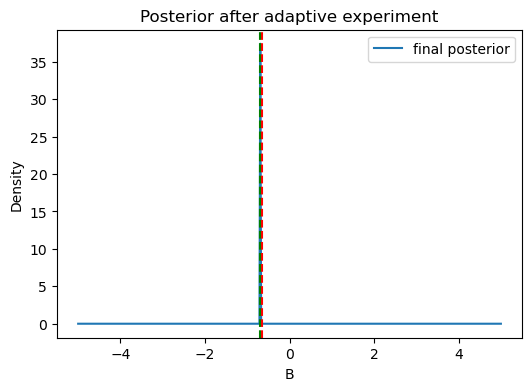

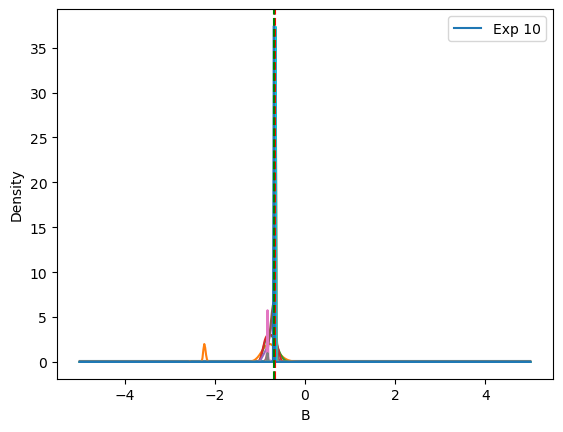

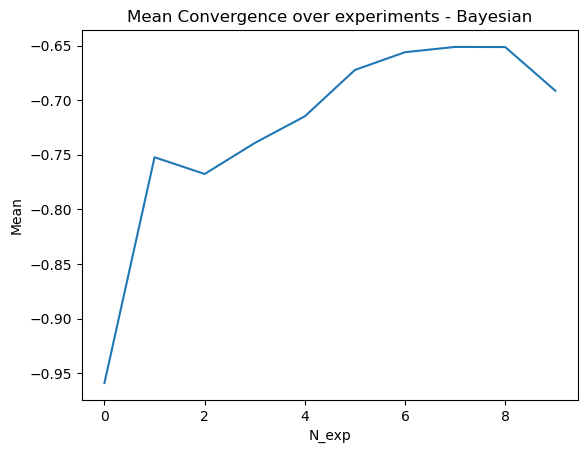

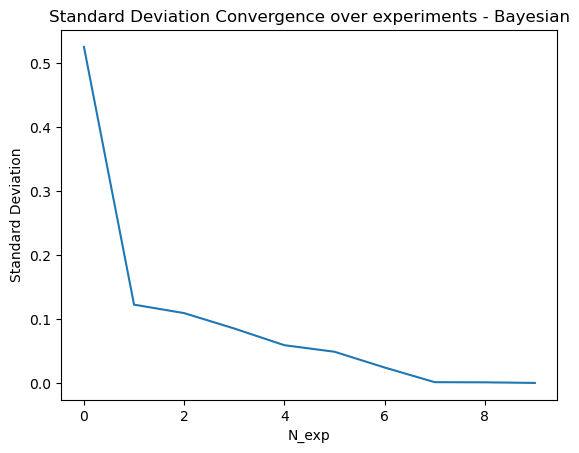

Bruh, you got major skill issues
Mean: -0.6913788827834627 , Mode: -0.6913827655310623 , StdDev: 0.0002798622561739667
2.5350701402805607 : 1.465948619594434 

1.472945891783567 : 3.098284461746883 

0.07014028056112204 : 3.140098874771113 

0.21042084168336653 : 1.9175240006187197 

1.3126252505010017 : 2.396526322438972 

0.7715430861723445 : 2.276489932097017 

0.7515030060120238 : 4.968447103760655 

0.5711422845691381 : 3.9377092832937386 

0.6513026052104206 : 5.744997187196865 

0.6513026052104206 : 5.9032170827783075 



<Figure size 640x480 with 0 Axes>

In [34]:
B_unk = np.random.uniform(-1, 1)  # B_unknown can be anything between -2 and 2
print("True B value =", B_unk)
N_exp = 10
Test = 0

# Plot final posterior and show chosen biases
Mean_MLE, StdDev_MLE = MLE(B_unk, B_bias, sigma, Test=0, num_samples=N_exp)
B_grid, posteriors, biases, xpected_kl, mean_MAP, mode_MAP, stddev_MAP = run_experiment(
    N_exp=N_exp,
    B_true=B_unk,
    sigma=2e-5,
    B_range=(-5, 5),
    n_grid=500,
    candidates=cp.linspace(-5, 5, 500),
    Test=Test,
    Gamma=0.01,
)
final_posterior = posteriors[-1]
area = simpson(final_posterior, B_grid)
print(f"Final posterior area (should be ~1): {area:.6f}")


new_dir = "Tests/Test_{Test}".format(Test=Test)
os.makedirs(new_dir, exist_ok=True)
save_path = os.path.join(new_dir, f"Final Posterior for Test {Test}.png".format(Test))
plt.figure(figsize=(6, 4))
plt.plot(B_grid, final_posterior, label="final posterior")
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(B_unk, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()
plt.savefig(save_path)


for i in range(len(posteriors)):
    line = plt.plot(B_grid, posteriors[i], label=f"Exp {i}")
    if i >= len(posteriors) - 5:
        plt.legend(handles=line)
plt.xlabel("B")
plt.ylabel("Density")
plt.axvline(B_unk, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()

save_path = os.path.join(new_dir, f"Mean Convergence MAP Test {Test}.png".format(Test))
plt.plot([i for i in range(N_exp)], mean_MAP, label=f"Mean Convergence")
plt.xlabel("N_exp")
plt.ylabel("Mean")
plt.title("Mean Convergence over experiments - Bayesian")
plt.show()
plt.savefig(save_path)

save_path = os.path.join(new_dir, f"Std Convergence MAP Test {Test}.png".format(Test))
plt.plot([i for i in range(N_exp)], stddev_MAP, label=f"Standard Deviation Convergence")
plt.xlabel("N_exp")
plt.ylabel("Standard Deviation")
plt.title("Standard Deviation Convergence over experiments - Bayesian")
plt.show()
plt.savefig(save_path)

if (mean_MAP[-1] - B_unk) ** 2 < (Mean_MLE - B_unk) ** 2:
    print("The Bayesian has promised.")
else:
    print("Bruh, you got major skill issues")

print("Mean:", mean_MAP[-1], ", Mode:", mode_MAP[-1], ", StdDev:", stddev_MAP[-1])
for i in range(len(biases)):
    print(biases[i], ":", xpected_kl[i], "\n")

Test 1


True B value = 0.9331652527767087
0.96024071028289 +- 0.04156952110652345 is the MLE-estimated value of B_unk, and the true value is 0.9331652527767087
Final posterior area (should be ~1): 1.000000
Final posterior area (should be ~1): 1.000000


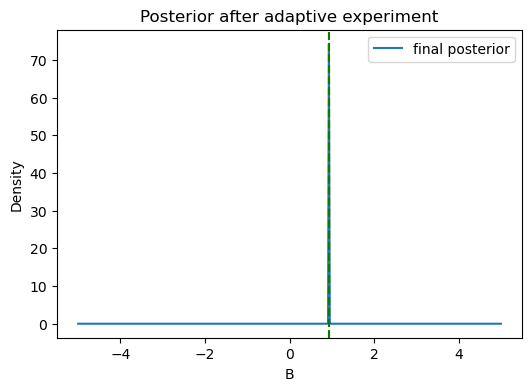

Bayesian Mean:  0.9319163997742597  with StdDev:  0.0016730591792809414
Final Estimation Error (Mean - True B) ** 2: 1.55963382172597e-06
Final Estimation StdDev: 0.0016730591792809414


<Figure size 640x480 with 0 Axes>

In [35]:
B_unk = np.random.uniform(-1, 1)  # B_unknown can be anything between -2 and 2
print("True B value =", B_unk)
N_exp = 10
Test = 1
Mean_MLE, StdDev_MLE = MLE(B_unk, B_bias, sigma, Test=0, num_samples=N_exp)
B_grid, posteriors, biases, xpected_kl, mean_MAP, mode_MAP, stddev_MAP = run_experiment(
    N_exp=N_exp,
    B_true=B_unk,
    sigma=2e-5,
    B_range=(-5, 5),
    n_grid=500,
    candidates=cp.linspace(-5, 5, 1000),
    Test=Test,
    Gamma=0.01,
)
final_posterior = posteriors[-1]
area = simpson(final_posterior, B_grid)
print(f"Final posterior area (should be ~1): {area:.6f}")


new_dir = "Tests/Test_{Test}".format(Test=Test)
os.makedirs(new_dir, exist_ok=True)
save_path = os.path.join(new_dir, f"Final Posterior for Test {Test}.png".format(Test))
plt.figure(figsize=(6, 4))
plt.plot(B_grid, final_posterior, label="final posterior")
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(B_unk, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()
plt.savefig(save_path)
print('Bayesian Mean: ', mean_MAP[-1], ' with StdDev: ', stddev_MAP[-1])
bayesian_delta = (mean_MAP[-1] - B_unk) ** 2
print("Final Estimation Error (Mean - True B) ** 2:", bayesian_delta)
bayesian_stdev = stddev_MAP[-1]
print("Final Estimation StdDev:", bayesian_stdev)

# run MLE fit on the data with increasing number of samples until the error of the MLE is better than the bayesian


In [36]:
def compare_MLE_Bayesian(B_unk, B_bias, sigma, bayesian_delta, N_exp, Test=1, show_plots=None):
    if show_plots is None:
        show_plots = SHOW_PLOTS
    num_samples = N_exp
    mle_delta_list = []
    index = 0
    while True:
        index += 1
        Mean_MLE, StdDev_MLE = MLE(
            B_unk, B_bias, sigma / (5 ** 0.5), Test=Test, num_samples=num_samples
        )
        mle_delta = (Mean_MLE - B_unk) ** 2
        mle_delta_list.append(mle_delta)
        print(
            "Num Samples:",
            num_samples,
            "\nMLE Estimation Error (Mean - True B) ** 2:",
            mle_delta,
        )
        print("MLE Estimation StdDev:", StdDev_MLE)
        if mle_delta < bayesian_delta:
            break
        num_samples += 1
    print("Number of samples required for MLE to beat Bayesian:", num_samples)
    if show_plots:
        plt.axhline(y=bayesian_delta, color='r', linestyle='--', label='Bayesian Error Threshold')
        plt.plot(
            [i for i in range(N_exp, len(mle_delta_list) + N_exp)],
            mle_delta_list,
            label="MLE Estimation Error vs Number of Samples",
        )
        plt.legend()
    return num_samples
# wrap this in a function and call this a 1000 times to get a histogram of num_samples required for MLE to beat Bayesian
print(compare_MLE_Bayesian(B_unk, B_bias, sigma, bayesian_delta, N_exp, Test=1))

0.7267948417534781 +- 0.01874302166958386 is the MLE-estimated value of B_unk, and the true value is 0.9331652527767087
Num Samples: 10 
MLE Estimation Error (Mean - True B) ** 2: 0.042588746545897144
MLE Estimation StdDev: 0.01874302166958386
0.9945997763303409 +- 0.05581016763004861 is the MLE-estimated value of B_unk, and the true value is 0.9331652527767087
Num Samples: 11 
MLE Estimation Error (Mean - True B) ** 2: 0.0037742006842617914
MLE Estimation StdDev: 0.05581016763004861
0.9069254006679474 +- 0.060530865868655484 is the MLE-estimated value of B_unk, and the true value is 0.9331652527767087
Num Samples: 12 
MLE Estimation Error (Mean - True B) ** 2: 0.000688529838689667
MLE Estimation StdDev: 0.060530865868655484
0.9913136253776251 +- 0.052769578567282496 is the MLE-estimated value of B_unk, and the true value is 0.9331652527767087
Num Samples: 13 
MLE Estimation Error (Mean - True B) ** 2: 0.0033812332361350087
MLE Estimation StdDev: 0.052769578567282496
-1.366929757282213

In [50]:
num_exps = 100
samples_list = []
# Use tqdm to show progress of repeated comparisons
for i in tqdm(range(num_exps), desc="Comparing MLE vs Bayesian"):
    samples_list.append(compare_MLE_Bayesian(B_unk, B_bias, sigma, bayesian_delta, N_exp, Test=1))

import numpy as np
import matplotlib.pyplot as plt
if SHOW_PLOTS:
    plt.show()

0.9049411648806545 +- 0.024537594651277687 is the MLE-estimated value of B_unk, and the true value is 0.9331652527767087
Num Samples: 10 
MLE Estimation Error (Mean - True B) ** 2: 0.0007965991375641954
MLE Estimation StdDev: 0.024537594651277687
0.9543695361735016 +- 0.022880433991285677 is the MLE-estimated value of B_unk, and the true value is 0.9331652527767087
Num Samples: 11 
MLE Estimation Error (Mean - True B) ** 2: 0.000449621634371508
MLE Estimation StdDev: 0.022880433991285677
1.0941821167110624 +- 0.009441950192050729 is the MLE-estimated value of B_unk, and the true value is 0.9331652527767087
Num Samples: 12 
MLE Estimation Error (Mean - True B) ** 2: 0.02592643047125416
MLE Estimation StdDev: 0.009441950192050729
0.9534794538949438 +- 0.019659256210222215 is the MLE-estimated value of B_unk, and the true value is 0.9331652527767087
Num Samples: 13 
MLE Estimation Error (Mean - True B) ** 2: 0.000412666767072105
MLE Estimation StdDev: 0.019659256210222215
0.92434477650177

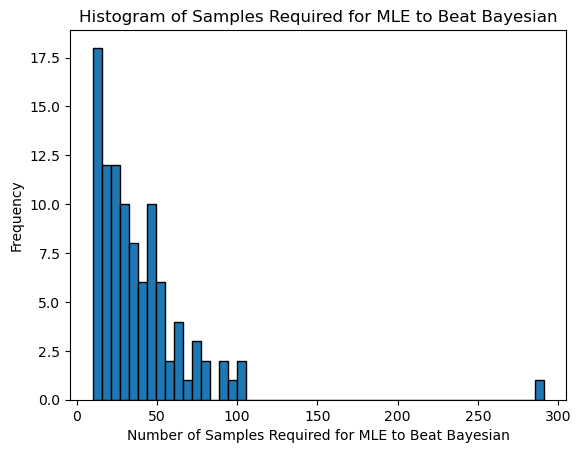

In [52]:
plt.hist(samples_list, bins=50, edgecolor='black')
plt.xlabel('Number of Samples Required for MLE to Beat Bayesian')
plt.ylabel('Frequency')
plt.title('Histogram of Samples Required for MLE to Beat Bayesian')
plt.show()


In [41]:
for i in tqdm(range(num_exps), desc="Repeating comparisons"):
    samples_list.append(compare_MLE_Bayesian(B_unk, B_bias, sigma, bayesian_delta, N_exp, Test=1))

0.9360791060037084 +- 0.011818409958530734 is the MLE-estimated value of B_unk, and the true value is 0.9331652527767087
Num Samples: 10 
MLE Estimation Error (Mean - True B) ** 2: 8.49054062849635e-06
MLE Estimation StdDev: 0.011818409958530734
-0.08077113870678782 +- 0.22931945973710152 is the MLE-estimated value of B_unk, and the true value is 0.9331652527767087
Num Samples: 11 
MLE Estimation Error (Mean - True B) ** 2: 1.0280670059745742
MLE Estimation StdDev: 0.22931945973710152
0.9654954705903426 +- 0.06398503587378726 is the MLE-estimated value of B_unk, and the true value is 0.9331652527767087
Num Samples: 12 
MLE Estimation Error (Mean - True B) ** 2: 0.0010452429838770092
MLE Estimation StdDev: 0.06398503587378726
0.9124058349114906 +- 0.020244810437419332 is the MLE-estimated value of B_unk, and the true value is 0.9331652527767087
Num Samples: 13 
MLE Estimation Error (Mean - True B) ** 2: 0.00043095343010273504
MLE Estimation StdDev: 0.020244810437419332
-0.19581845798008

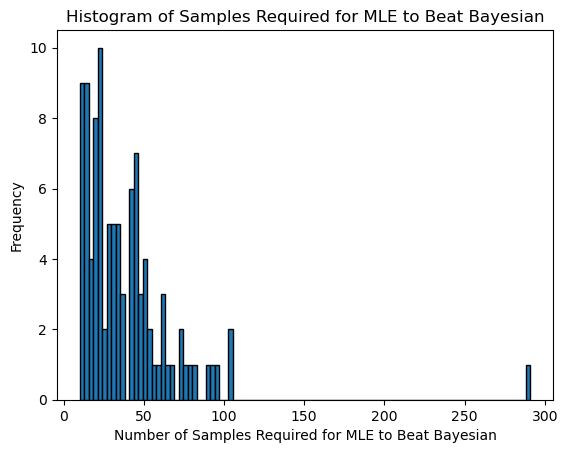

In [55]:
plt.hist(samples_list, bins=100, edgecolor='black')
plt.xlabel('Number of Samples Required for MLE to Beat Bayesian')
plt.ylabel('Frequency')
plt.title('Histogram of Samples Required for MLE to Beat Bayesian')
plt.show()

In [40]:
# TODO: compare with frequentist zero crossing approach: give quantitative estimate of:
# 1. amount of readings required for both
# 2. accuracy of estimate for both
# 3. inference time for both
# 
# 2. interpretability
# 3. adaptive simpson
# 4. mcmc
# 6. adaptive grid refinememtn
# 7. vectorisation of likelihood
